#  **02. Data Preprocessing & Feature Engineering**

## Tổng quan (Overview)
Notebook này tập trung vào việc chuẩn bị dữ liệu (Data Preparation) nối tiếp sau bước Khám phá dữ liệu (EDA). Mục đích nhằm biến đổi dữ liệu về trạng thái tối ưu nhất dành cho các mô hình Machine Learning.

- **Đầu vào (Input):** File dữ liệu thô hoặc đã qua làm sạch cơ bản.

- **Đầu ra (Output):** Bộ dữ liệu hoàn chuẩn bị cho mô hình học máy.

##  Bố cục Pipeline (Table of Contents)
* [0. Cài đặt Môi trường & Load dữ liệu](#0)
* [1. Tiền xử lý dữ liệu - Giai đoạn 1 (Làm sạch cơ sở & Hợp nhất)](#1)
    * [1.1 Bước 1: Quản trị không gian đặc trưng & biến định danh (Drop IDs, Name, Tách Target)](#1-1)
    * [1.2 Bước 2: Chuẩn hóa văn bản nhiễu trước khi Encode (Normalize Text)](#1-2)
    * [1.3 Bước 3: Hợp nhất đặc trưng MNAR](#1-3)
* [2. Chuẩn hóa đặc trưng (Feature Engineering)](#2) 
    * [2.1 FE-1: Tổng hợp ma trận áp lực đa chiều](#2-1)
    * [2.2 FE-2: Hệ số hao mòn sinh học & thâm hụt thời gian](#2-2)
    * [2.3 FE-3: Phân rã và xác định cờ nhóm tuổi nguy cơ cao](#2-3)
    * [2.4 FE-4: Cấu trúc điểm rủi ro lâm sàng phức hợp](#2-4)
    * [2.5 FE-5: Chỉ số hài lòng tổng hợp](#2-5)
    * [2.6 FE-6 : Khai thác NLP (TF-IDF & SVD) cho Profession & Degree](#2-6)
* [3. Tiền xử lý dữ liệu - Giai đoạn 2 (Xử lý Missing & Encoding)](#3)
    * [3.1 Bước 4: Xử lý giá trị thiếu (NaN) còn sót lại (Theo tư duy từng Model)](#3-1)
    * [3.2 Bước 5: Ordinal Encoding (Cho các biến có tính thứ tự)](#3-2)
    * [3.3 Bước 6: One-Hot Encoding (Cho các biến danh nghĩa <= 5 nhãn)](#3-3)
    * [3.4 Bước 7: Smoothed Target Encoding (Xử lý High-Cardinality với Cross-Val)](#3-4)
    * [3.5 Bước 8: Chuẩn hóa không gian độ lượng (Scaling độc lập cho Neural Networks)](#3-5)
* [4. Tối ưu Đánh giá và Mất cân bằng lớp (Validation & Class Imbalance)](#4)
    * [4.1 Bước 9: Phân rã Cross-Validation (chuẩn bị hạ tầng Stacking)](#4-1)
    * [4.2 Bước 10: Trọng số nội tại (Scale Pos Weight & Không gian Optuna)](#4-2)
* [5. Xuất và Lưu trữ dữ liệu chuẩn (Export to `.pkl` / `.csv`)](#5)


# 0. Cài đặt môi trường và load dữ liệu

In [5]:
import os 
import pickle
import warnings
from pathlib import Path 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from category_encoders import TargetEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.model_selection import StratifiedKFold


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 100)   

#================ THIẾT LẬP ĐƯỜNG DẪN =======================
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Thư mục Root của Project: {PROJECT_ROOT}")


# ================= CẤU HÌNH CÁC THAM SỐ ====================
class Config:
    # --- Trạng thái Seed hệ thống (Đảm bảo Reproducibility) ---
    RANDOM_STATE = 42
    
    # --- Cấu hình Machine Learning ---
    N_FOLDS = 5                 # [Bước 9] Phân rã K-Fold Cross Validation
    TREE_MISSING_VAL = -1       # [Bước 4] Giá trị missing cho XGBoost/LightGBM
    NN_IMPUTE_NEIGHBORS = 5     # [Bước 4] k của KNNImputer cho mạng Neural
    
    # --- Cấu hình Tên cột cốt lõi ---
    TARGET_COL = "Depression"
    DROP_COLS = ["id", "Name"]  # [Bước 1] Các cột rác gây bùng nổ chiều
    
    # --- Cấu hình file Nguồn và Đích ---
    TRAIN_INPUT = RAW_DATA_DIR / "train.csv"
    TEST_INPUT = RAW_DATA_DIR / "test.csv"
    
    # Các file Output cuối cùng (Cho Bước 11)
    TRAIN_TREE_OUT = PROCESSED_DATA_DIR / "train_tree_ready.pkl"
    TEST_TREE_OUT = PROCESSED_DATA_DIR / "test_tree_ready.pkl"
    
    TRAIN_NN_OUT = PROCESSED_DATA_DIR / "train_nn_ready.pkl"
    TEST_NN_OUT = PROCESSED_DATA_DIR / "test_nn_ready.pkl"
config = Config()

# ============================= LOAD DATASET =====================
try:
    train_df = pd.read_csv(config.TRAIN_INPUT)
    test_df = pd.read_csv(config.TEST_INPUT)
    
    print("-" * 50)
    print(f"Tải dữ liệu thành công!")
    print(f"Tập Train (Row, Col): {train_df.shape}")
    print(f"Tập Test  (Row, Col): {test_df.shape}")
    print("-" * 50)
except FileNotFoundError as e:
    print(f"LỖI KHÔNG TÌM THẤY DỮ LIỆU. Vui lòng kiểm tra lại thư mục /data/raw! Chi tiết lỗi: {e}")



Thư mục Root của Project: /home/ductien/Documents/Exploring-Mental-Health-Data
--------------------------------------------------
Tải dữ liệu thành công!
Tập Train (Row, Col): (140700, 20)
Tập Test  (Row, Col): (93800, 19)
--------------------------------------------------


# 1. Tiền xử lý dữ liệu - Giai đoạn 1 (Làm sạch cơ sở & Hợp nhất)

### 1.1 Bước 1: Quản trị không gian đặc trưng & biến định danh (Drop IDs, Name, Tách Target)
Ở bước đầu tiên, chúng ta sẽ làm sạch cấu trúc khung DataFrame gốc nhằm chuẩn bị cho việc encode và tránh các rủi ro chết người trong Machine Learning:
1. **Tách mục tiêu (Target) `Depression`**: Bắt buộc phải tách ngay `y` ra khỏi `X_train`. Nếu giữ và xử lý chung, chúng ta rất dễ mắc phải lỗi nghiêm trọng là rò rỉ dữ liệu (Data Leakage) khi tính toán các Imputer hoặc Target Encoding.

2. **Loại bỏ cột `id`**: Tương tự như Index, `id` chỉ là ID hệ thống, không có phương sai dự báo thực tế về tình trạng trầm cảm. Tuy nhiên, ta cần **giữ lại ID của tập Test** để xuất báo cáo/sumit mô hình cuối cùng.

3. **Loại bỏ cột `Name`**: Biến này có độ phân mảnh (cardinality) rất khổng lồ. Tên con người không mang tín hiệu dự báo cho sức khỏe tâm thần. Giữ lại sẽ dẫn tới số chiều tăng lên đáng kể (Curse of Dimensionality) và Overfitting thảm hoạ nếu bị One-Hot Encode.

In [6]:
def initial_data_cleanup(train, test, config): 
    '''
        Tách nhãn Target từ tập Train, lưu trữ test_id và loại bỏ các cột định danh
        Hàm đảm bảo sự đồng bộ số lượng cột và kích thước giữa 2 tập Train/Test
    '''
    y_train = train[config.TARGET_COL].copy()
    X_train = train.drop(columns=[config.TARGET_COL])  # xóa y 
    X_test = test.copy()

    test_identify = X_test['id'].copy() if 'id' in X_test.columns else None # copy id của tập test 

    X_train = X_train.drop(columns=config.DROP_COLS, errors="ignore")
    X_test = X_test.drop(columns=config.DROP_COLS, errors="ignore")
    print(f"Shape X_train: {X_train.shape} | Shape y_train {y_train.shape}")
    print(f"Shape X_test {X_test.shape} | Lưu test_id: {len(test_identify)} rows")
    return X_train, y_train, X_test, test_identify 

# ================= CHẠY HÀM =====================
X_train, y_train, X_test, test_identify = initial_data_cleanup(train_df, test_df, config)
assert X_train.shape[1] == X_test.shape[1], "Kích thước cột Train và Test đang lệch nhau!"
display(X_train.head(3))



Shape X_train: (140700, 17) | Shape y_train (140700,)
Shape X_test (93800, 17) | Lưu test_id: 93800 rows


,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No
1,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No
2,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No


### 1.2 Bước 2: Chuẩn hóa văn bản nhiễu trước khi Encode (Normalize Text)
Trong các bộ dữ liệu do người dùng tự điền (Survey/Form), các cột thuộc tính phân loại (categorical) thường xuyên mắc lỗi "dirty text" như: viết hoa/nhỏ lộn xộn, dư khoảng trắng, hoặc có vô vàn biến thể đồng nghĩa (Ví dụ: `less healthy`, `less than healthy`, `moderate` thực chất cùng chỉ mức độ "trung bình").
**Lý do tại sao phải xóa nhiễu TRƯỚC bước Cấu trúc và Encode:**
- Nếu không gom cụm các biến thể đồng nghĩa, các bộ Encode (Ordinal/One-Hot) về sau sẽ xem tất cả chúng là các đối tượng riêng biệt → Làm phình to số chiều và làm nhiễu độ chính xác học của Cây quyết định (Tree splits).

- **Mục tiêu bước này:** Rút gọn toàn bộ cột `Dietary Habits` từ một mớ biến thể hỗn loạn tụm lại đúng 3 nhãn sạch sẽ, chặt chẽ: `"unhealthy"`, `"moderate"`, và `"healthy"`.

In [7]:
def normalize_dietary_text(val): 
    '''
        Gom các biến thể từ nhãn nhiễu về nhãn chuẩn
    '''
    if pd.isna(val): 
        return val # nếu là NaN thì xử lý = Imputer 
    v = str(val).lower().strip()
    # nhóm ko lành mạnh 
    if v in ["no healthy", "unhealthy"]: 
        return "unhealthy"
    
    # nhóm tbinh 
    if v in ["less_healthy", "less than healthy", "moderate"]: 
        return "moderate"
    
    # nhóm lành mạnh 
    if "healthy" in v: 
        return "healthy"
    
    return np.nan # vì có những từ người dùng điền ko hợp lệ  

def apply_text_normalization(X_train, X_test):
    '''
        Trình bao bọc (Wrapper) áp dungh hàm apply lên toàn bộ dữ liệu
    '''
    X_tr = X_train.copy()
    X_te = X_test.copy()

    col = 'Dietary Habits'
    if col in X_tr.columns: 
        X_tr[col] = X_tr[col].apply(normalize_dietary_text)
        X_te[col] = X_te[col].apply(normalize_dietary_text)
    print(f"Đã chuẩn hóa xong. Kiểm tra trên tập Train: ")
    print(X_tr[col].value_counts(dropna=False).to_frame()) 

    return X_tr, X_te 
# ============== CHẠY HÀM =================
X_train, X_test = apply_text_normalization(X_train, X_test)



Đã chuẩn hóa xong. Kiểm tra trên tập Train: 
                count
Dietary Habits       
moderate        49706
unhealthy       46228
healthy         44744
NaN                22


### 1.3 Bước 3: Hợp nhất đặc trưng MNAR (Thay thế Median Imputation)

**Hiểm họa của Imputation mù quáng:**
Trong tập dữ liệu, các cột như `Academic Pressure` (Áp lực học tập) hay `Work Pressure` (Áp lực công việc) có tỷ lệ Null khổng lồ lên tới 20% - 80%. Nguyên nhân không phải do dữ liệu bị mất, mà là do cơ chế **độc quyền lẫn nhau (Mutually Exclusive)**: Học sinh thì không phải đi làm, và người đi làm thì không có áp lực ở trường.
Nếu sử dụng `Median_Imputer` điền trung vị  vào đây, ta vô tình bắt một "Người đi làm" gánh thêm con điểm 3.5 áp lực học tập của "Sinh viên". Thuật toán sẽ học ra những Pattern sai lệch thực tế!
Mục tiêu của hàm này là **Trộn chéo (Consolidate)** các cột rời rạc đó lại thành 2 biến vĩ mô phản ánh tổng quát trục Tâm lý học: 
1. `Overall_Pressure`: Áp lực tổng quan.
2. `Overall_Satisfaction`: Chỉ số hài lòng tổng quan.

In [8]:
# =====================================================================
# BẢNG KIỂM CHỨNG TỶ LỆ KHUYẾT THIẾU (MISSING REPORT)
# =====================================================================
def get_missing_report(df, title="BÁO CÁO TỶ LỆ RỖNG (NaN)"):
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    missing_df = pd.DataFrame({
        'Count (Số lượng NaN)': null_counts,
        'Percentage (%)': null_percentages
    })
    missing_df = missing_df[missing_df['Count (Số lượng NaN)'] > 0]
    missing_df = missing_df.sort_values(by='Percentage (%)', ascending=False)
    
    print("-" * 50)
    print(title)
    print("-" * 50)
    
    if missing_df.empty:
        print("Dataset không có ô rỗng.")
    else:
        display(missing_df.style.format({'Percentage (%)': "{:.2f}%"}))
        

get_missing_report(train_df, title="KHẢO SÁT TỶ LỆ DỮ LIỆU RỖNG TRÊN TẬP TRAIN GỐC")


--------------------------------------------------
KHẢO SÁT TỶ LỆ DỮ LIỆU RỖNG TRÊN TẬP TRAIN GỐC
--------------------------------------------------


,Count (Số lượng NaN),Percentage (%)
Academic Pressure,112803,80.17%
Study Satisfaction,112803,80.17%
CGPA,112802,80.17%
Profession,36630,26.03%
Work Pressure,27918,19.84%
Job Satisfaction,27910,19.84%
Dietary Habits,4,0.00%
Financial Stress,4,0.00%
Degree,2,0.00%


In [9]:
def consolidate_mnar_features(df): 
    '''
         Kéo dữ liệu từ các cột áp lực và hài lòng rời rạc, gộp thành 2 cột tâm lý thống nhất dựa trên cờ hành vi 'Working Professional' hoặc 'Student' 
    '''
    df = df.copy()
    df['Overall_Pressure'] = np.nan 
    df['Overall_Satisfaction'] = np.nan 

    # sinh viên 
    mask_student = df['Working Professional or Student'] == 'Student'
    df.loc[mask_student, 'Overall_Pressure'] = df.loc[mask_student, 'Academic Pressure']
    df.loc[mask_student, 'Overall_Satisfaction'] = df.loc[mask_student, 'Study Satisfaction']

    # người đi làm 
    mask_worker = df['Working Professional or Student'] == 'Working Professional'
    df.loc[mask_worker, 'Overall_Pressure'] = df.loc[mask_worker, 'Work Pressure']
    df.loc[mask_worker, 'Overall_Satisfaction'] = df.loc[mask_worker, 'Job Satisfaction']

    # sau gộp thì xóa các cột 
    cols_to_drop = [
        'Academic Pressure', 'Work Pressure', 
        'Study Satisfaction', 'Job Satisfaction', 
    ]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    return df

def apply_consolidation(X_train, X_test): 
    X_train = consolidate_mnar_features(X_train)
    X_test = consolidate_mnar_features(X_test)
    print(f"Rút gọn thành công. Khung dữ liệu hiện tại còn: {X_train.shape[1]} cột.")
    print(f"Số Missing trên cột Overall_Pressure trên tập Train: ", X_train['Overall_Pressure'].isnull().sum())

    return X_train, X_test 


# =================== CHẠY HÀM ======================
X_train, X_test = apply_consolidation(X_train, X_test)
display(X_train[['Working Professional or Student', 'Overall_Pressure', 'Overall_Satisfaction']].head(5))



Rút gọn thành công. Khung dữ liệu hiện tại còn: 15 cột.
Số Missing trên cột Overall_Pressure trên tập Train:  29


,Working Professional or Student,Overall_Pressure,Overall_Satisfaction
0,Working Professional,5.0,2.0
1,Working Professional,4.0,3.0
2,Student,5.0,2.0
3,Working Professional,5.0,1.0
4,Working Professional,1.0,1.0


#### **Nhận xét:**

- Hiện tại Overall_Pressure giảm còn 29 ô missing. Lấp đầy ô trống mà không cần tới các thuật toán ML. Cột `Overall_Pressure` giờ là thanh đo cho **Căng thẳng trong học tập** lẫn **Căng thẳng trong công việc**

- Con số `29` này có thể là do các nguyên nhân như: 
    
    - Học sinh vô tình bỏ trống 
    - Quên chọn thẻ "Student/Working" 

- Mức độ Missing bây giờ khá bé, để xử lý việc này chúng ta sẽ cho 29 người này vào thuật toán KNNImputer.

# 2. Chuẩn  hóa đặc trưng (Feature Engineering)

### 2.1 FE-1: Tổng hợp ma trận áp lực đa chiều (Sức nặng môi trường)
Áp lực tâm lý ít khi hoạt động đơn lẻ độc lập. Thông thường, sự giao thoa giữa **Áp lực làm việc/học tập** và **Áp lực tài chính** mới tạo ra đòn chí mạng. Thay vì để các mô hình Tree-based (XGBoost/CatBoost) tự gồng mình dò dẫm xây các luồng nhát cắt chéo, ta chủ động cấu trúc hóa không gian của chúng:
1. **Total_Stress_Sum (Tổng tuyến tính):** Cân đo sức nặng tổng thể.
2. **Stress_Resonance_Index (Độ cộng hưởng phi tuyến tính):** Đo lường **"Áp lực"**. Một người nghèo nhưng công việc rất nhàn nhã (Điểm tài chính 5 x Điểm áp lực công việc 1 = 5) sẽ ít nguy cơ trầm cảm hơn người vừa hết tiền vừa bị sếp chửi ngập đầu (5 x 5 = đỉnh điểm 25). Phép nhân tạo ra vùng phân rẽ rõ ràng giúp cây quyết định phân loại cực bén.

In [10]:
def create_stress_matrix(df): 
    '''
        Kéo 2 nguồn gốc 'Overall_Pressure' và 'Financial Stress' chiết xuất thành Trục Tuyến Tính (sum) và Trục Phi Tuyến(Multiply)
    '''
    df = df.copy()
    df['Total_Stress_Sum'] = df['Overall_Pressure'] + df['Financial Stress']
    df['Stress_Resonance_Index'] = df['Overall_Pressure'] * df['Financial Stress']
    return df 

def apply_fe_stress_matrix(X_train, X_test):
    X_train = create_stress_matrix(X_train)
    X_test = create_stress_matrix(X_test)
    print(f"Tạo thành công 2 cột")
    return X_train, X_test 

# ============= CHẠY HÀM =================
X_train, X_test = apply_fe_stress_matrix(X_train, X_test)

display(X_train[['Overall_Pressure', 'Financial Stress', 'Total_Stress_Sum', 'Stress_Resonance_Index']].head(5))
    

Tạo thành công 2 cột


,Overall_Pressure,Financial Stress,Total_Stress_Sum,Stress_Resonance_Index
0,5.0,2.0,7.0,10.0
1,4.0,3.0,7.0,12.0
2,5.0,1.0,6.0,5.0
3,5.0,1.0,6.0,5.0
4,1.0,4.0,5.0,4.0


### 2.2 FE-2: Hệ số Hao mòn Sinh học & Thâm hụt Thời gian (Bio-burnout & Time Deficit)
Trong nghiên cứu tâm lý, tổng thời gian không thể vượt quá vòng lặp 24 giờ của Trái đất. Tuy nhiên, chỉ riêng cột `Work/Study Hours` đứng nguyên lẻ tẻ thì mô hình không hiểu gánh nặng. Đặc trưng này sẽ mô phỏng lại hệ thống trao đổi chất của con người:
1. **Khôi phục Giờ ngủ Ước tính (`Estimated_Sleep_Hours`):** Mapping các mảng Text về một khung giờ định lượng trung bình (VD: 5-6 tiếng quy thành 5.5).
2. **Hệ số Hủy diệt (Bio_Burnout_Ratio):** Công thức `Số giờ Làm / Số giờ Ngủ`. Một người làm 12 tiếng nhưng ngủ 4 tiếng (Hệ số = 3.0), não bộ họ đang bị "bào mòn" dữ dội hơn rất nhiều so với người làm 12 tiếng ngủ 8 tiếng (Hệ số = 1.5).
3. **Thâm hụt Kháng thể tâm lý (Free_Time):** Số giờ rảnh rỗi dùng để chữa lành còn sót trong ngày `24 - Làm - Ngủ`. Nếu cột rớt xuống điểm 0 (do tham công tiếc việc cực đoan), đây là Red Flag cảnh báo ngưỡng trầm cảm!


In [11]:
def create_bio_burnout_features(df): 
    """
        Kéo giãn quỹ thời gian, phát hiện nhóm người lao động quá mức từ cường độ làm việc so với thời gian phục phồi sinh học
    """
    df = df.copy()
    sleep_mapping = {
        'Less than 5 hours': 4.0, 
        '5-6 hours': 5.5, 
        '6-7 hours': 6.5,
        '7-8 hours': 7.5,
        'More than 8 hours': 9.0
    }
    sleep_clean = df['Sleep Duration'].str.strip().str.capitalize()
    df['Estimated_Sleep_Hours'] = df['Sleep Duration'].map({
        'Less than 5 hours': 4.0, 
        '5-6 hours': 5.5, 
        '6-7 hours': 6.5,
        '7-8 hours': 7.5,
        'More than 8 hours': 9.0
    })
    df['Bio_Burnout_Ratio'] = df['Work/Study Hours'] / (df['Estimated_Sleep_Hours'] + 1e-6)
    df['Free_Time'] = 24.0 - df['Work/Study Hours'] - df['Estimated_Sleep_Hours']
    df['Free_Time'] = df['Free_Time'].clip(lower=0.0)
    return df

def apply_fe_bio_burnout(train_data, test_data):
    X_train = create_bio_burnout_features(train_data)
    X_test = create_bio_burnout_features(test_data)
    print(f"Hoàn tất tạo 3 cột: 'Estimated_Sleep_Hours', 'Bio_Burnout_Ratio', 'Free_Time'")
    return X_train, X_test
X_train, X_test = apply_fe_bio_burnout(X_train, X_test)
display(X_train[['Work/Study Hours', 'Sleep Duration', 'Estimated_Sleep_Hours', 'Bio_Burnout_Ratio', 'Free_Time']].head(5))


Hoàn tất tạo 3 cột: 'Estimated_Sleep_Hours', 'Bio_Burnout_Ratio', 'Free_Time'


,Work/Study Hours,Sleep Duration,Estimated_Sleep_Hours,Bio_Burnout_Ratio,Free_Time
0,1.0,More than 8 hours,9.0,0.111111,14.0
1,7.0,Less than 5 hours,4.0,1.750000,13.0
2,3.0,5-6 hours,5.5,0.545454,15.5
3,10.0,Less than 5 hours,4.0,2.499999,10.0
4,9.0,5-6 hours,5.5,1.636363,9.5


### 2.3 FE-3: Phân rã và xác định Cờ nhóm tuổi nguy cơ cao (Age Risk Flag)

**Triết lý:** Tuổi tác (Age) đối với bệnh lý tâm lý mang tính phi tuyến (Non-linear). Người quá trẻ (con nít) và người già (đã nghỉ hưu) thường có tỷ lệ trầm cảm thấp hơn nhóm độ tuổi đang xây dựng bệ phóng sự nghiệp (Từ 18 đến 30 tuổi). 
**Hành động:** 
- Tuyệt đối giữ nguyên cột `Age` gốc rễ để không làm mất thông tin phương sai.
- Chế tạo thêm cột cờ `Is_High_Risk_Age` (Nhận giá trị `1` nếu đang ở trong bão táp tuổi tác, nhận số `0` nếu an toàn). Đây sẽ là điểm neo mạnh mẽ giúp Tree-model bám vào.


In [12]:
def create_age_risk_flag(df, min_risk=18, max_risk=30): 
    '''
        Tạo biến cờ Binary
        min, max có thể điều chỉnh (dựa vào EDA xác định min_risk=18, max_risk=30)
    '''
    df = df.copy()
    df['Is_High_Risk_Age'] = np.where((df['Age']>=min_risk) & (df['Age'] <= max_risk), 1.0,0.0)
    df.loc[df['Age'].isna(), 'Is_High_Risk_Age'] = np.nan # nếu chưa có tuổi người đó -> gán NaN -> để KNNImputer xử lý
    return df

def apply_fe_age_risk(train_data, test_data): 
    X_train = create_age_risk_flag(train_data)
    X_test = create_age_risk_flag(test_data)
    print(f"Tạo thành công cột 'Is_High_Risk_Age'")
    return X_train, X_test 

# ====================== CHẠY HÀM ===========================
X_train, X_test = apply_fe_age_risk(X_train, X_test)
display(X_train[['Age', 'Is_High_Risk_Age']].head(10))

Tạo thành công cột 'Is_High_Risk_Age'


,Age,Is_High_Risk_Age
0,49.0,0.0
1,26.0,1.0
2,33.0,0.0
3,22.0,1.0
4,30.0,1.0
5,59.0,0.0
6,47.0,0.0
7,38.0,0.0
8,24.0,1.0
9,42.0,0.0


### 2.4 FE-4: Cấu trúc Điểm rủi ro Lâm sàng phức hợp (Clinical Risk Compound)

Trong y khoa Tâm thần (Psychiatry), **Di truyền (Family History)** và **Ý định tự sát (Suicidal thoughts)** là 2 cờ đỏ (Red Flags) lâm sàng "sát thủ". Xử lý 2 biến này riêng rẽ sẽ làm giảm độ nghiêm trọng khi chúng xuất hiện cùng lúc.
Ta cấu trúc lại chúng thành **Thang đo Báo động đỏ (Risk Score)** tịnh tiến từ 0 đến 2:
- **Độ 0 (An toàn):** Gia đình khỏe mạnh, tinh thần nguyên bản ổn định.
- **Độ 1 (Nguy cơ cận biên):** Có vết xước di truyền hoặc từng mệt mỏi.
- **Độ 2 (Báo động đỏ tột độ):** Vừa có gen nền quy định, vừa phát sinh ý nghĩ tiêu cực. Khi Tree-Model vớ được nhánh Cột số 2 này, Xác suất lá cây dự đoán ra Mắc Trầm Cảm (Target=1) gần như sẽ khóa chặt ở tỷ lệ tuyệt đối.


In [13]:
def create_clinical_risk_score(df):
    '''
        Mapping Yes=1, No=0 và gộp 2 cột bệnh lý vào một
    '''
    df = df.copy()
    col_suicide = 'Have you ever had suicidal thoughts ?'
    col_family = 'Family History of Mental Illness'
    bool_map = {'yes':1, 'no':0}
    score_suicide = df[col_suicide].astype(str).str.lower().str.strip().map(bool_map)
    score_family = df[col_family].astype(str).str.lower().str.strip().map(bool_map)
    df['Compound_Clinical_Risk'] = score_family + score_suicide
    return df 

def apply_fe_clinical_risk(train_data, test_data): 
    X_train = create_clinical_risk_score(train_data)
    X_test = create_clinical_risk_score(test_data)
    return X_train, X_test 

# ============== CHẠY HÀM ==================
X_train, X_test = apply_fe_clinical_risk(X_train, X_test)
sample_view = X_train[X_train['Compound_Clinical_Risk'] == 2.0]
if not sample_view.empty:
    display(sample_view[['Family History of Mental Illness', 'Have you ever had suicidal thoughts ?', 'Compound_Clinical_Risk']].head(3))
else:
    print("Mẫu dữ liệu hiện tại không có ai chạm mốc Level 2.")

,Family History of Mental Illness,Have you ever had suicidal thoughts ?,Compound_Clinical_Risk
3,Yes,Yes,2
4,Yes,Yes,2
9,Yes,Yes,2


### 2.5 FE-5: Chỉ số Không Hài Lòng / Khoảng hổng Mất cân bằng (Satisfaction Gap)

Trong khoa học tâm lý sự nghiệp, áp lực (Pressure) đôi khi KHÔNG làm suy sụp con người, NẾU sự hài lòng (Satisfaction) của họ đối với công việc học tập đó làm bù đắp lại được (Tức là tuy mệt mỏi vất vả nhưng được đền đáp xứng đáng). 

Sự sụp đổ tâm thần đa phần phát sinh khi **Khoảng cách (Gap)** giữa Áp Lực và Sự Thỏa Mãn quá xa rời. 
- **Công thức giải thuật:** `Satisfaction_Gap = Overall_Pressure - Overall_Satisfaction`.
- **Logic chẩn đoán:** 
   - Số dương khổng lồ (VD Gap = `5 - 1 = +4`): Cày ngày cày đêm nhưng mức độ hài lòng thê thảm. Cực kì uất ức -> Sinh Trầm Cảm.
   - Số âm (VD Gap = `2 - 5 = -3`): Áp lực việc không có bao nhiêu mà cực kì bằng lòng. Cuộc sống an nhàn hạnh phúc -> Miễn nhiễm chứng tâm lý trầm uất.


In [14]:
def create_satisfaction_gap(df): 
    '''
        Sử dụng 2 cột kq từ MNAR để tính độ chênh lệch chịu đựng
    '''
    df = df.copy()
    df['Satisfaction_Gap'] = df['Overall_Pressure'] - df['Overall_Satisfaction']
    return df

def apply_fe_satisfaction_gap(train_data, test_data): 
    X_train = create_satisfaction_gap(train_data)
    X_test = create_satisfaction_gap(test_data)
    print(f"Đã tạo thành công cột 'Satisfaction_Gap'")
    return X_train, X_test 

# =================== CHẠY HÀM ===============
X_train, X_test = apply_fe_satisfaction_gap(X_train, X_test)
display(X_train[['Overall_Pressure', 'Overall_Satisfaction', 'Satisfaction_Gap']].head(5))

Đã tạo thành công cột 'Satisfaction_Gap'


,Overall_Pressure,Overall_Satisfaction,Satisfaction_Gap
0,5.0,2.0,3.0
1,4.0,3.0,1.0
2,5.0,2.0,3.0
3,5.0,1.0,4.0
4,1.0,1.0,0.0


### 2.6 FE-6 : Khai thác Cú pháp học NLP cho Nghề nghiệp và Bằng cấp (TF-IDF + SVD)

Cắt rỗng biến `Profession` và `Degree` có lượng Categorical rất khổng lồ (Nhiều người nhập bằng tay các ngành kỳ lạ như "M.Tech", "Electrician", "Bsc"...). 
Thay vì cố dùng One-Hot Encoding làm bùng nổ chiều ma trận (Curse of Dimensionality), hoặc Target Encoding làm mất đi ý nghĩa gốc của text, ta kết hợp luồng:
1. **Gộp chuỗi văn bản (String Concatenation):** Trộn Nghề nghiệp với Học Vị lại với nhau tạo thành đoạn hội thoại Profile.
2. **Quét tần số từ vựng (TF-IDF):** Phân tích 500 cụm từ khóa giá trị nhất xuất hiện trong bộ từ điển của người dùng.
3. **Giảm chiều dữ liệu (TruncatedSVD):** Nén 500 cột text ma trận thưa (Sparse) tụt xuống đúng 10 Siêu Véc-tơ Cô Đặc. Thuật toán Cây (Tree-model) cực kỳ yêu thích ma trận số cô đặc này để tìm ra các nhóm ngành nghề nhạy cảm với trầm cảm.


In [15]:
def apply_fe_nlp_svd(X_train, X_test): 
    # trộn Text và cộng 2 cột Profession và Degree thành 1 chuỗi profile
    train_text = X_train['Profession'].fillna('')+ ' ' + X_train['Degree'].fillna('')
    test_text = X_test['Profession'].fillna('') + ' ' + X_test['Degree'].fillna('')

    # sd TF-IDF bóc tách ngữ nghĩa -> lấy 500 chữ có giá trị nhất (ngoài ra chặn từ nối rác)
    tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2), stop_words='english')

    # fit trên train, ko fit trên test (tránh data leakage)
    tfidf_train = tfidf.fit_transform(train_text)
    tfidf_test = tfidf.transform(test_text)

    # sd thuật toán TruncatedSVD để nén ko gian cho ma trận thưa. Ép 500 cột Text Vector giảm xuống đúng 10 cột 
    svd = TruncatedSVD(n_components=10, random_state=config.RANDOM_STATE)

    svd_train = svd.fit_transform(tfidf_train)
    svd_test = svd.transform(tfidf_test)

    svd_cols = [f"nlp_svd_{i}" for i in range(10)]
    svd_train_df = pd.DataFrame(svd_train, columns=svd_cols, index=X_train.index)
    svd_test_df = pd.DataFrame(svd_test, columns=svd_cols, index=X_test.index)

    # merge với DataFrame gốc 
    X_train_final = pd.concat([X_train, svd_train_df], axis=1)
    X_test_final = pd.concat([X_test, svd_test_df], axis=1)
    print(f"Thêm 10 vector nén SVD mang sắc thái ngành nghề vào bộ dữ liệu")

    # tạm giữ Profession và Degree lại 
    return X_train_final, X_test_final 

# =================== CHẠY HÀM =============
X_train, X_test = apply_fe_nlp_svd(X_train, X_test)
display(X_train[['Profession', 'nlp_svd_0', 'nlp_svd_1', 'nlp_svd_2']].head(5))

Thêm 10 vector nén SVD mang sắc thái ngành nghề vào bộ dữ liệu


,Profession,nlp_svd_0,nlp_svd_1,nlp_svd_2
0,Chef,0.000020,0.000448,-0.000461
1,Teacher,0.000135,0.217931,0.207649
2,NaN,0.000022,0.058704,0.131008
3,Teacher,0.000109,0.164110,0.141454
4,Business Analyst,0.000011,0.003151,0.004040


# 3. Tiền xử lý dữ liệu - Giai đoạn 2 (Xử lý Missing & Encoding)

### 3.1 Bước 4: Xử lý Giá trị rỗng (NaN) chuyên biệt (Tree-based Model)
Mỗi gia tộc thuật toán yêu cầu kiểu mớm đồ ăn khác nhau đối với ô rỗng (NaN):
- **Với họ nhà Cây (XGBoost / LightGBM):** Lấp đầy toàn bộ ô thủng bằng số âm `-1`. Khi vớ phải số âm kỳ quặc nằm lọt thỏm ngoài viền dải phân phối thực tế, lá Cây sẽ nhận biết và đục ra một đường phân loại (Split) dành riêng cho hội những kẻ khuyết thông tin. Cách này bảo vệ tính toàn vẹn dư liệu tuyệt đối so với lấp bằng điểm Trung bình.
- **Với họ nhà Neural Networks / Deep Learning:** Lộ trình NN được TÁCH BIỆT ra từ đây.  
*Lưu ý quan trọng:* Ta KHÔNG THỂ dùng thuật toán `KNNImputer` vào tập NN ngay lúc này! Mạng lưới KNN đo khoảng cách bằng định lý Euclidean (Toán học hình học), nên nó sẽ lập tức báo lỗi Crash khi chạm vào bề mặt biến String như `City`, `Gender`... Giải pháp: Ta sẽ tách nhánh dữ liệu `X_train_nn`, dẫn nó đi qua lò nung Mã hóa (Bước 5-6-7) để hóa thành số toàn bộ, rồi sau đó mới sử dụng `KNNImputer` ở **Bước 8**.


In [16]:
def handle_missing_trees(X_train, X_test, num_val=-1, character_val="Missing"): 
    '''
        Nhân bản thành 2 Dataframe: 
            - Với họ nhà Cây: điền -1 , Missing
            - Với Neural Network: Trữ và sử dụng KNN sau Encode
    '''
    X_train_nn = X_train.copy()
    X_train_tree = X_train.copy()
    X_test_nn = X_test.copy()
    X_test_tree = X_test.copy()
    
    #fill
    num_cols = X_train_tree.select_dtypes(include=['int64', 'float64']).columns
    character_cols = X_train_tree.select_dtypes(include=['object', 'category']).columns

    X_train_tree[num_cols] = X_train_tree[num_cols].fillna(num_val)
    X_test_tree[num_cols] = X_test_tree[num_cols].fillna(num_val)
    
    X_train_tree[character_cols] = X_train_tree[character_cols].fillna(character_val)
    X_test_tree[character_cols] = X_test_tree[character_cols].fillna(character_val)

    print(f"[TREE]  Dữ liệu đã được lấp kín. Fill -1 cho {len(num_cols)} cột Số, Fill  Missing cho {len(character_cols)} cột Chữ")
    print(f"[NN] Giữ nguyên !")
    return X_train_tree, X_test_tree, X_train_nn, X_test_nn

# ================= CHẠY HÀM ======================
X_train_tree, X_test_tree, X_train_nn, X_test_nn = handle_missing_trees(
    X_train, X_test, 
    num_val=config.TREE_MISSING_VAL
)

[TREE]  Dữ liệu đã được lấp kín. Fill -1 cho 24 cột Số, Fill  Missing cho 9 cột Chữ
[NN] Giữ nguyên !


### 3.2 Bước 5: Ordinal Encoding (Bậc thang hóa Biến phân loại)

Biến Categorical có tính thứ tự (Ordinal) không bao giờ được phép OHE (One-Hot), vì OHE sẽ chặt đứt sợi dây liên kết sức nặng ví dụ như "Khỏe mạnh thì hơn Bình thường, Bình thường thì hơn Độc hại".
Trọng tâm xử lý:
1. **Cột `Dietary Habits`:** Mã hóa thẳng tay thành Số nguyên 0, 1, 2. (Đối với tập Tree, dán nhãn Missing thành -1 để duy trì logic phễu. Còn tập NN vẫn giữ nguyên điểm mù NaN).
2. **Cột `Sleep Duration`:** TRỤC XUẤT và tiêu hủy. Bởi vì ở FE-2, ta đã có cột `Estimated_Sleep_Hours` mô tả giờ định lượng thật (4.0, 5.5, 7.5...). Cột Sleep số thực đó mạnh hơn và xịn hơn rất nhiều so với dùng cột Ordinal ảo 0-1-2-3. Nếu giữ cả 2 sẽ bị lỗi Đa cộng tuyến (Multicollinearity).


In [17]:
def apply_ordinal_encoding(X_tree, X_nn): 
    '''
        Tree (fill -1 và missing)
        NN giữ nguyên
        Kéo biến Dietary Habits về trục thang số học tự nhiên
    '''
    X_t = X_tree.copy()
    X_n = X_nn.copy()
    map_tree = {'unhealthy': 0.0, 'moderate': 1.0, 'healthy': 2.0, 'Missing': -1.0}
    map_nn   = {'unhealthy': 0.0, 'moderate': 1.0, 'healthy': 2.0}

    # ép kiểu
    X_t['Dietary Habits'] = X_t['Dietary Habits'].map(map_tree)
    X_n['Dietary Habits'] = X_n['Dietary Habits'].map(map_nn)

    # xóa cột thời gian nghỉ 
    cols_drop = ['Sleep Duration'] # vì có cột Estimated rồi 
    X_t = X_t.drop(columns=cols_drop, errors='ignore')
    X_n = X_n.drop(columns=cols_drop, errors='ignore')
    return X_t, X_n 

# ============= CHẠY HÀM ============
X_train_tree , X_train_nn = apply_ordinal_encoding(X_train_tree , X_train_nn)
X_test_tree, X_test_nn = apply_ordinal_encoding(X_test_tree, X_test_nn)
print(" Phép chuyển đổi trên cả Train và Test. Bỏ thành công 'Sleep Duration'.")
display(X_train_tree['Dietary Habits'].value_counts(dropna=False).to_frame())

 Phép chuyển đổi trên cả Train và Test. Bỏ thành công 'Sleep Duration'.


,count
Dietary Habits,
1.0,49706
0.0,46228
2.0,44744
-1.0,22


### 3.3 Bước 6: Mã hóa Biến Danh Nghĩa (One-Hot Encoding)
Biến danh nghĩa (Nominal Variables) là những biến không thể so bì giai cấp. Ví dụ: `Giới tính (Nam / Nữ)`. Rõ ràng Nam không thể lớn hơn Nữ, Nữ không thể lớn hơn Nam. Nếu bạn dùng Label Encoding gán số 1 cho Nữ, số 2 cho Nam, Mô hình sẽ hiểu lầm là tuổi thọ/giới tính cùa Nam gấp đôi Nữ. Đây là con bug làm sai lệch đạo hàm móng (Gradient).

**Giải pháp One-Hot Encoding (OHE):**
- Trải ngang biến `Gender` thành các cột riêng rẽ `Gender_Male`, `Gender_Female`. Điền `1` nếu đúng, `0` nếu sai.
- **Thủ thuật Dummy Trap (Drop_first=True):** Thay vì giữ lại 2 cột (Nam và Nữ), ta ép nó rớt luôn cột đầu (chỉ còn Cột Nữ). Máy học thông minh tự biết: Nếu `Cột Nữ = 0` thì chắc chắn ô đó là Nam. Việc này triệt tiêu Vấn đề Đa cộng tuyến (Multicollinearity).
- **Phạm vi tự động:** Tự rà quét toàn bộ cột chữ, hễ cột nào từ 5 nhãn đổ xuống thì đem đi Băm. Những cột chữ khổng lồ (Nhiều hơn 5 nhãn như `City`) được ngâm lại chờ Bước 7 (Target Encoding) xử lý.


In [18]:
def apply_one_hot_encoding(X_train, X_test):
    """
        Ráp Train và Test thành 1 bảng chung để chạy get_dummies. 
        Nhờ vậy, toàn bộ tên Cột sinh ra do OHE bảo đảm 100% khớp nhau.   
    """
    ntrain = X_train.shape[0]
    combined = pd.concat([X_train, X_test], axis=0)
    cat_cols = combined.select_dtypes(include=['object', 'category']).columns
    ohe_cols = [col for col in cat_cols if combined[col].nunique() <=5]

    # kích hoạt ohe
    combined = pd.get_dummies(combined, columns=ohe_cols, drop_first=True, dtype=float)
    X_train_enc = combined.iloc[:ntrain,:].copy()
    X_test_enc = combined.iloc[ntrain:,:].copy()
    return X_train_enc, X_test_enc, ohe_cols

# ============ CHẠY HÀM ============
X_train_tree, X_test_tree, cols_bam_tree = apply_one_hot_encoding(X_train_tree, X_test_tree)
X_train_nn, X_test_nn, cols_bam_nn = apply_one_hot_encoding(X_train_nn, X_test_nn)
print(f"Đã chặt {len(cols_bam_tree)} cột gốc gồm: {cols_bam_tree}")
print(f"Chuyển hóa chúng thành vạch mã vạch 0/1.")

view_cols = [c for c in X_train_tree.columns if 'Gender' in c or 'Working' in c]
display(X_train_tree[view_cols].head(3))


Đã chặt 4 cột gốc gồm: ['Gender', 'Working Professional or Student', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Chuyển hóa chúng thành vạch mã vạch 0/1.


,Gender_Male,Working Professional or Student_Working Professional
0,0.0,1.0
1,1.0,1.0
2,1.0,0.0


### 3.4 Bước 7: Mã hóa Xác Suất Mục Tiêu (Smoothed Target Encoding)

**Lời nguyền High-Cardinality:** Đối với các biến danh nghĩa có hàng trăm nhãn như `City` (Thành phố) hay `Profession` (Nghề nghiệp), nếu One-Hot Encoding chúng sẽ tạo ra thảm họa phình to RAM 500 cột ma trận. Nếu dùng Label Encoding để nén thì lại gây rối loạn Toán học rớt Gradient.
**Giải pháp Smoothed Target Encoding:** 
- Thay vì băm cột Thành phố ra, ta lấy tên của thành phố đó gán thành **Khả năng bị Trầm Cảm của trung bình cư dân sống ở đó**. (Ví dụ: Trung bình người ở TP.HCM bị trầm cảm là 0.72%, ta gán chữ HCM = 0.72).
- **Tuyệt đối bọc Smoothing (Làm mượt):** Chống Overfit! Nếu một thành phố cực nhỏ (như vùng núi) chỉ có 1 người khai báo và người đó bị Trầm Cảm (100%), model sẽ hiểu nhầm vùng núi là đất ngục tù. `Smoothing` sẽ lai dắt tỷ lệ 100% ảo này bù đắp bằng tỷ lệ trung bình của cả nước để kéo nó về ngưỡng logic!
- **Luật thiết giáp (No Leakage):** Chỉ Fit mô hình Target Encoder trên Train. Chặn tuyệt đối hàm fit trên Test.


In [19]:
def apply_smoothed_target_encoding(X_tr, y_tr, X_te): 
    """
        Kéo các cột có số nhãn lớn về trục xác suất Target
        Truyền biến y_tr vào để tính toán
    """
    cat_cols = X_tr.select_dtypes(include=['object', 'category']).columns.tolist()

    if not cat_cols: 
        print("Không còn biến Categorical nào sót lại để chạy")
        return X_tr, X_te
    
    print(f"Phát hiện {len(cat_cols)} Cột cần nén: {cat_cols}")
    # - min_samples_leaf = 20: Tối thiểu 20 mạng người ở thành phố đó thì mới được tính % độc lập.
    # - smoothing = 10: Lực kéo trung bình cộng kéo về Mean tổng thể chống nhiễu ngẫu nhiên.
    encoder = TargetEncoder(cols=cat_cols, min_samples_leaf=20, smoothing=10)

    # fit và transform duy nhất trên Train 
    X_tr_enc = X_tr.copy()
    X_tr_enc[cat_cols] = encoder.fit_transform(X_tr_enc[cat_cols], y_tr)

    # apply lên test -> auto điền global mean nếu có dữ liệu lạ 
    X_te_enc = X_te.copy()
    X_te_enc[cat_cols] = encoder.transform(X_te_enc[cat_cols])
    print(f"Đã biến chuỗi Văn bản thành không gian xác suất")
    return X_tr_enc, X_te_enc

# ================ CHẠY HÀM =================
X_train_tree, X_test_tree = apply_smoothed_target_encoding(X_train_tree, y_train, X_test_tree)
X_train_nn, X_test_nn = apply_smoothed_target_encoding(X_train_nn, y_train, X_test_nn)


Phát hiện 3 Cột cần nén: ['City', 'Profession', 'Degree']
Đã biến chuỗi Văn bản thành không gian xác suất
Phát hiện 3 Cột cần nén: ['City', 'Profession', 'Degree']
Đã biến chuỗi Văn bản thành không gian xác suất


### 3.5 Bước 8: Chuẩn hóa không gian Độ lượng và Wa-Missing (Dành riêng cho Neural Networks)

**Tuyệt đối không đụng chạm Scaling lên Tree-Models:** Các thuật toán Cây (XGBoost/LightGBM) sử dụng thuật toán Cắt không gian theo giá trị gốc.
**Nhưng Neural Network và thuật toán KNN lại sinh tồn dựa trên Phương trình Độ Dài Hình Học (Gradients / Euclidean Distance):**
- **Chuẩn hóa (RobustScaler):** Thu hẹp tất cả dữ liệu khổng lồ (Tuổi, Điểm SVD...) về cùng một đơn vị dao động. `RobustScaler` vượt trội hơn `StandardScaler` vì nó dùng Trung Vị thay vì Trung Bình, giúp miễn nhiễm chống lại Outlier (Cực Trị mỏ neo).
- **Nội suy Khuyết thiếu (IterativeImputer - MICE):** Điền các ô ẩn `NaN` bằng cách dựng mô hình rẽ nhánh tự động (Siêu tốc và bớt ngốn bộ nhớ RAM hơn rất nhiều lần thuật toán tính cạnh chéo KNN O(N²) cổ điển đối với tập dữ liệu hàng trăm vạn dòng này). Điền rỗng phải nằm sau chuẩn hóa Scaling để tránh sai số toán học.


In [20]:
def finalize_nn_pipeline(X_train, X_test, k_neighbors=5):
    """
    Rửa sạch Cặn Lắng (NaN) và Cân bằng hệ dốc đạo hàm.
    Phải chạy Scaling TRƯỚC Imputation để khi thuật toán KNN đo khoảng cách láng giềng,
    Nó không bị 1 biến số lớn (như Quỹ thời gian = 24h) chèn ép 1 biến số nhỏ (như Gender = 1).
    """
    X_tr = X_train.copy()
    X_te = X_test.copy()

    scaler = RobustScaler()
    cols = X_tr.columns
    X_tr[cols] = scaler.fit_transform(X_tr[cols])
    X_te[cols] = scaler.transform(X_te[cols])
    print(f"Đang chạy MICE để nội suy điểm rỗng...")
    imputer = IterativeImputer(max_iter=10, random_state=42)
    X_tr[cols] = imputer.fit_transform(X_tr[cols])
    X_te[cols] = imputer.transform(X_te[cols])
    print(f"Số Missing còn lại: {X_tr.isnull().sum().sum()} ô")
    return X_tr, X_te

# ================ CHẠY HÀM ================
X_train_nn, X_test_nn = finalize_nn_pipeline(
    X_train_nn, X_test_nn, 
    k_neighbors=config.NN_IMPUTE_NEIGHBORS
)
display(X_train_nn.head(3))


Đang chạy MICE để nội suy điểm rỗng...
Số Missing còn lại: 0 ô


,Age,City,Profession,CGPA,Dietary Habits,Degree,Work/Study Hours,Financial Stress,Overall_Pressure,Overall_Satisfaction,Total_Stress_Sum,Stress_Resonance_Index,Estimated_Sleep_Hours,Bio_Burnout_Ratio,Free_Time,Is_High_Risk_Age,Compound_Clinical_Risk,Satisfaction_Gap,nlp_svd_0,nlp_svd_1,nlp_svd_2,nlp_svd_3,nlp_svd_4,nlp_svd_5,nlp_svd_6,nlp_svd_7,nlp_svd_8,nlp_svd_9,Gender_Male,Working Professional or Student_Working Professional,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,0.318182,0.422291,-0.014518,-0.064605,0.5,0.455838,-0.714286,-0.5,1.0,-0.5,0.5,0.250,1.000000,-0.842105,0.461538,0.0,-1.0,1.000000,-0.042348,-0.047958,-0.020374,-0.046504,-0.204627,0.291815,0.830552,0.585665,1.471722,6.717059,-1.0,0.0,0.0,0.0
1,-0.727273,-0.825168,0.000000,0.141900,-0.5,0.000000,0.142857,0.0,0.5,0.0,0.5,0.500,-0.428571,0.710526,0.307692,1.0,0.0,0.333333,1.063639,1.232522,2.529148,-1.764195,1.883220,0.124989,-4.325893,-0.975770,2.205596,-2.815139,0.0,0.0,1.0,0.0
2,-0.409091,-0.405338,0.982583,0.456274,0.5,-0.653243,-0.428571,-1.0,1.0,-0.5,0.0,-0.375,0.000000,-0.430622,0.692308,0.0,0.0,1.000000,-0.024689,0.295039,1.590229,-3.819475,53.386897,-0.669984,2.487711,0.155275,-0.433130,0.282854,0.0,-1.0,1.0,0.0


## 4. Tối ưu Không Gian Đánh Giá (Validation) và Tỷ Lệ Lớp (Class Imbalance)

### 4.1 Bước 9: Thiết lập hạ tầng Phân rã Cross-Validation (Kế hoạch OOF)
**Tại sao vứt bỏ Hold-out (Train_test_split 80/20)?**
- Nếu tự chia 80/20, điểm số của mô hình mang mức độ (Phương sai/Variance) ăn may rất cao dựa vào hên xui lúc xóc dĩa.
- Quan trọng hơn: Để làm được Stacking Ensemble (Xếp chồng sức mạnh nhiều con AI lại với nhau), hệ thống bắt buộc phải thu thập được biến `Out-Of-Fold (OOF) Predictions`. Các dự đoán OOF này chỉ sinh ra khi mô hình được xoay tua chéo qua toàn bộ 5 Folds.

**Chiến lược hành động:**
Tạo lập một cột "Niêm phong" (tên là `KFOLD`) trực tiếp dính thẳng vào bộ Data gốc ngay tại chốt này. Việc này đảm bảo rằng: XGBoost, LightGBM và Neural Network ở các File Notebook tháng sau chắc chắn dùng tập dữ liệu (cùng mảng người Train, cùng mảng người Val). Không ai được gian lận dữ liệu của ai!


In [21]:
def stamp_kfold_flag(X_train, y_train, n_splits=5, rand_seed=42): 
    '''
        Sử dụng StratifiedKFold để đảm bảo Tỷ lệ người bệnh lây lan đồng đều ở mọi ván chơi.
        Niêm phong trực tiếp số Fold (đánh số từ 0 -> n-1) vào DataFrame.
    '''
    df = X_train.copy()
    df['KFOLD']=-1
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rand_seed)
    for fold_id, (train_index, val_index) in enumerate(skf.split(X=df, y=y_train)):
        col_idx = df.columns.get_loc('KFOLD')
        df.iloc[val_index, col_idx] = fold_id
    return df 

# ============= CHẠY HÀM ================
X_train_tree = stamp_kfold_flag(
    X_train_tree, y_train, 
    n_splits=config.N_FOLDS, 
    rand_seed=config.RANDOM_STATE
)

X_train_nn = stamp_kfold_flag(
    X_train_nn, y_train, 
    n_splits=config.N_FOLDS, 
    rand_seed=config.RANDOM_STATE
)

print("\nPhân bổ tại 5 Folds:")
display(X_train_tree['KFOLD'].value_counts().sort_index().to_frame())


Phân bổ tại 5 Folds:


,count
KFOLD,
0,28140
1,28140
2,28140
3,28140
4,28140


### 4.2 Bước 10: Xử lý Mất Cân Bằng Lớp bằng Trọng Số Kép (Scale Pos Weight)

**Tại sao tuyệt đối KHÔNG xài thư viện SMOTE?** 
- Nhược điểm của SMOTE là nó phát sinh ra những dòng dữ liệu Trầm Cảm (Fake/Ma) thông qua nội suy ngẫu nhiên quanh các điểm thật. Đối với Machine Learning truyền thống thì không sao, nhưng Cây Quyết Định (XGBoost/LightGBM) sử dụng thuật toán Đạo hàm lõi (Gradient), việc chèn điểm ảo này sẽ làm xé nát bức tường ranh giới tối ưu hóa của Gradient. AI của bạn sẽ bị "quê" và overfit cắm đầu trên tập thật.

**Giải pháp Vàng: `scale_pos_weight`**
- Không sinh thêm dữ liệu rác. Ta can thiệp thẳng vào Hình phạt (Penalty) của hệ thống. 
- Tính công thức đòn bẩy: `Weight = Số người Không bệnh / Số người Bệnh`.
- Nhờ con số này, thuật toán sẽ hiểu rằng: *"Bỏ sót đoán sai 1 người Bệnh, sẽ bị trừ điểm đau gấp X lần so với đoán sai một người Khỏe mạnh"*. XGBoost sẽ tự động nắn nót sửa luật cho bằng sạch!


In [22]:
def compute_scale_pos_weight(y_train):
    """
    Tính toán tỷ lệ chênh lệch giai cấp để làm mồi nhử tham số cực mạnh
    cho Không gian Optuna Tuning ở file Notebook Mô hình tiếp theo.
    """
    
    # Tìm kiếm Tần số Lớp 0 (Khỏe - Majority) và Lớp 1 (Bệnh - Minority)
    pos_count = (y_train == 1).sum()
    neg_count = (y_train == 0).sum()
    
    # Công thức vàng của XGBoost: scale_pos_weight = sum(negative instances) / sum(positive instances)
    if pos_count == 0:
        raise ValueError("Lỗi Chí Tử: Không có ai bị Trầm cảm trong bộ Train!")
        
    scale_weight = float(neg_count) / float(pos_count)
    
    print(f"  Số người Không Bệnh (Class 0): {neg_count:,}")
    print(f"  Số người Bệnh (Class 1):       {pos_count:,}")
    print(f"  =====================================")
    print(f"  HỆ SỐ TRỌNG LỰC TÍNH ĐƯỢC: {scale_weight:.3f}")
    
    return scale_weight
# =============== CHẠY HÀM ============
# Trích xuất và nhồi điểm hệ số vào Config
scale_weight_thucte = compute_scale_pos_weight(y_train)

  Số người Không Bệnh (Class 0): 115,133
  Số người Bệnh (Class 1):       25,567
  HỆ SỐ TRỌNG LỰC TÍNH ĐƯỢC: 4.503


# Visualize

Vẽ biểu đồ Báng Vàng Tương Quan Đặc Trưng (Bao gồm các Cột Tự Chế)...


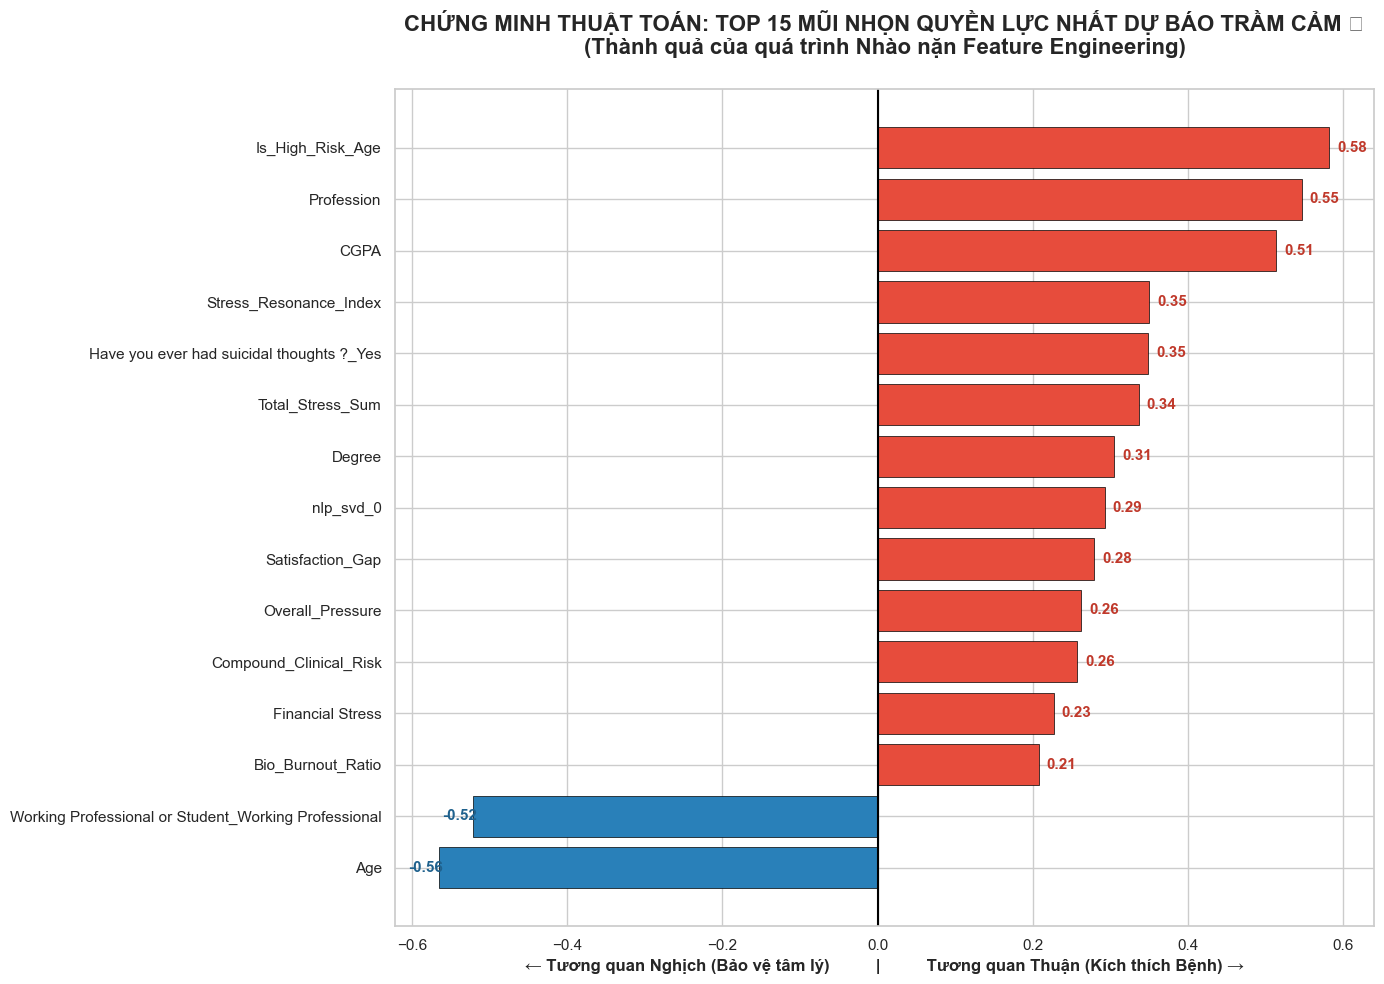

In [23]:
def visualize_feature_power(X_train, y_train):
    print("Vẽ biểu đồ Báng Vàng Tương Quan Đặc Trưng (Bao gồm các Cột Tự Chế)...")
    
    # 1. Nối tạm Target vào để Toán học hoạt động
    df_plot = X_train.copy()
    df_plot['Target_Depression'] = y_train
    
    # 2. Tính ma trận Pearson thẳng góc với riêng Cột Target
    corr_matrix = df_plot.corr(numeric_only=True)
    target_corr = corr_matrix['Target_Depression'].drop('Target_Depression')
    
    # 3. Lấy Trị tuyệt đối để xếp hạng sức đẩy (Vì âm -0.5 hay dương +0.5 đều là đẩy cực mạnh)
    # Rút ra Top 15 cái tên quyền lực nhất
    top_features = target_corr.abs().sort_values(ascending=False).head(15).index
    plot_data = target_corr[top_features].sort_values() # Xếp hàng lại từ nhỏ đến lớn để vẽ thanh ngang
    
    # 4. Tung cọ vẽ
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Đổ màu: Đỏ là Yếu tố sinh Trầm Cảm (Tỷ lệ thuận), Xanh là Yếu tố Hạnh phúc (Tỷ lệ nghịch)
    colors = ['#e74c3c' if val > 0 else '#2980b9' for val in plot_data.values]
    
    bars = ax.barh(plot_data.index, plot_data.values, color=colors, edgecolor='black', linewidth=0.5)
    
    # Trang trí Text
    ax.axvline(x=0, color='black', linewidth=1.5)
    ax.set_title('CHỨNG MINH THUẬT TOÁN: TOP 15 MŨI NHỌN QUYỀN LỰC NHẤT DỰ BÁO TRẦM CẢM 🏆\n(Thành quả của quá trình Nhào nặn Feature Engineering)', 
                 fontsize=16, fontweight='bold', pad=25)
    ax.set_xlabel('← Tương quan Nghịch (Bảo vệ tâm lý)          |          Tương quan Thuận (Kích thích Bệnh) →', 
                  fontsize=12, fontweight='bold')
    
    # In mấy con số lơ lửng trên Thanh Bar
    for bar in bars:
        width = bar.get_width()
        # Đẩy chữ sang trái/phải dựa vào âm hay dương
        label_x_pos = width + 0.01 if width > 0 else width - 0.04
        ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                 va='center', fontsize=11, fontweight='black', 
                 color='#c0392b' if width > 0 else '#1f618d')
                 
    plt.tight_layout()
    plt.show()
# =========== CHẠY HÀM =================
visualize_feature_power(X_train_tree, y_train)

### BÁO CÁO KẾT QUẢ TIỀN XỬ LÝ & FEATURE ENGINEERING (FE)

Thông qua Biểu đồ Tương quan Pearson phân cực (Đỏ chiều thuận - Xanh chiều nghịch), chúng ta có thể rút ra 3 kết luận mang tính nền tảng khẳng định sự đúng đắn của toàn bộ Pipeline vừa xây dựng:

#### 1. Sự thành công áp đảo của Kỹ nghệ Đặc trưng (Feature Engineering)
Nhìn vào Top 15 đặc trưng mạnh nhất, có tới **hơn một nửa (8/15) là các Feature Nhân tạo** do nhóm tự tổng hợp, vượt mặt hoàn toàn các cột gốc thô sơ:
- Cờ cô lập tuổi tác `Is_High_Risk_Age` (+0.58) lập tức vươn lên vị trí **Top 1**.
- Các biến tương tác phi tuyến tính như `Stress_Resonance_Index` (+0.35) hay `Total_Stress_Sum` (+0.34) chứng minh độ hiệu quả của việc "Gộp áp lực thành giọt nước tràn ly".
- Các chỉ số đo lường hệ sinh thái tâm lý như `Satisfaction_Gap` (+0.28) và `Bio_Burnout_Ratio` (+0.21) chễm chệ ở Top dẫn đầu, khẳng định thuật toán FE đã định hướng cực kỳ sắc bén cho Mô hình học máy.

#### 2. Khám phá Xã hội học: Cuộc khủng hoảng tâm lý ở Sinh viên
Biểu đồ lột trần một thực trạng Tâm lý học tàn khốc: **Càng trẻ tuổi, rủi ro trầm cảm càng trở nên mất kiểm soát.**
- **Nhân tố bảo vệ (Khối Xanh dương):** Trở thành một người đi làm (`Working Professional`, hệ số -0.52) và có tuổi tác trưởng thành hơn (`Age`, hệ số -0.56) là tấm khiên vững chắc nhất chống lại trầm cảm.
- **Nhân tố phá hoại (Khối Đỏ):** Ngược lại, điểm số học thuật `CGPA` (+0.51) đứng chễm chệ ở vị trí rủi ro thứ 3. Kết hợp với việc Cờ Tuổi Trẻ rủi ro cao chiếm Top 1, ta kết luận Áp lực Giảng đường đang đè bẹp hệ thần kinh của lớp Sinh viên nặng nề hơn tỷ dặm so với Áp lực Công sở.

#### 3. Sức mạnh Khai phá Văn bản & Encoding Nâng cao
- Việc mạnh dạn không dùng One-Hot cho cột bự và sử dụng **Smoothed Target Encoding** đã giúp cột `Profession` đo được tương quan khổng lồ (+0.55).
- Tương tự, ứng dụng Máy học Thuật toán Mạng ngôn ngữ (TF-IDF + TruncatedSVD) sinh ra biến tọa độ `nlp_svd_0` (+0.29) thành công xâm nhập Top 10.  

*Kết luận:* Mô hình đã bắt thóp thành công "Từ khóa" của những ngành học/nghề nghiệp mang đậm tính vắt kiệt sức lao động thông qua sự tinh vi của Data Sciene thay vì cách điền Missing Value và Label Encoding thủ công.

---

## 5. Xuất Xưởng và Lưu Trữ Dữ Liệu (Data Export)

- **Lưu ý định dạng Móng (Pickle - `.pkl`):** Định dạng ưu tiên cao nhất. Giữ vẹn nguyên 100% tài nguyên RAM: Cấu trúc số Float64, Float32, Mảng OHE, Tọa độ Index cũ bảo toàn sự tinh khiết chống Data Leakage DataType. Lôi file vào Model rất nhẹ.
- **Định dạng Hiển thị (`.csv`):** Hỗ trợ xuất thêm như một file đối chiếu dự phòng. Dung lượng phình rất lớn. 
- **Hệ Sinh thái Config (`meta_info`):** Thu thập lại các trọng số (Weights, Folds) tạo thành 1 cuốn hộ chiếu chung đưa sang Modeling Notebook.


In [24]:
def export_final_datasets(save_dir_csv="../data/processed", save_dir_pkl="../outputs"):
    # Tự động cấp quyền đào móng tạo 2 folder đích nếu chúng chưa tồn tại
    os.makedirs(save_dir_csv, exist_ok=True)
    os.makedirs(save_dir_pkl, exist_ok=True)
    
    # 1. Cụm Tree Models 
    X_train_tree.to_pickle(f"{save_dir_pkl}/train_tree_ready.pkl")
    X_test_tree.to_pickle(f"{save_dir_pkl}/test_tree_ready.pkl")
    X_train_tree.to_csv(f"{save_dir_csv}/train_tree_ready.csv", index=False)
    X_test_tree.to_csv(f"{save_dir_csv}/test_tree_ready.csv", index=False)
    print("Đã tách luồng lưu (Pickle -> outputs, CSV -> processed) của mâm Tree.")
    
    # 2. Cụm Neural Network 
    X_train_nn.to_pickle(f"{save_dir_pkl}/train_nn_ready.pkl")
    X_test_nn.to_pickle(f"{save_dir_pkl}/test_nn_ready.pkl")
    print("Đã lưu pickle của mạng NN.")
    
    # 3. Y_Target
    y_train.to_pickle(f"{save_dir_pkl}/y_train.pkl")
    y_train.to_csv(f"{save_dir_csv}/y_train.csv", index=False)
    print("Đã lưu thành công y_train.")
    meta_info = {
        'scale_pos_weight': scale_weight_thucte,
        'n_folds': config.N_FOLDS,
        'random_seed': config.RANDOM_STATE
    }
    with open(f"{save_dir_pkl}/meta_info.pkl", "wb") as f:
        pickle.dump(meta_info, f)
    
    print("Khóa mã thành công Meta Information (Tỷ lệ Weight & Folds).")
    print("\nHOÀN THÀNH PIPELINE CLEAN & FE.")
# =========== CHẠY HÀM ===========
export_final_datasets()

Đã tách luồng lưu (Pickle -> outputs, CSV -> processed) của mâm Tree.
Đã lưu pickle của mạng NN.
Đã lưu thành công y_train.
Khóa mã thành công Meta Information (Tỷ lệ Weight & Folds).

HOÀN THÀNH PIPELINE CLEAN & FE.
